# Regional Clustering of the Bolivian Energy System

This notebook implements a weighted K-Medoids clustering methodology to aggregate
sub-national regions into energy-homogeneous clusters. The approach combines
energy-infrastructure, climatic, renewable-resource, and socio-economic indicators
with geodesic distances in a hybrid distance matrix.

**Method overview**

| Step | Description |
|------|-------------|
| 1 | Standardize continuous variables; keep binary variables unscaled |
| 2 | Apply expert-defined feature weights |
| 3 | Build a hybrid distance matrix (weighted Euclidean + geodesic) |
| 4 | Evaluate optimal *k*  via Elbow, Silhouette, and Gap Statistic |
| 5 | Select *k** = round(mean of individual optima) |
| 6 | Run K-Medoids clustering (`k = K_CLUSTERS`) |

> **Requirements:** `scikit-learn-extra`, `geopy`, `geopandas`, `matplotlib`, `seaborn`


In [1]:
# =============================================================================
# 0. DEPENDENCIES
# =============================================================================

import sys, subprocess

try:
    import kmedoids
    print("kmedoids package found.")
except ImportError:
    print("Installing kmedoids...")
    subprocess.run([sys.executable, "-m", "pip", "install", "kmedoids", "-q"], check=True)
    import kmedoids

!pip install geopandas pyogrio

kmedoids package found.


Data ready: 21 municipalities, k range [2, 20], 100 iterations/k

Computing inertia & silhouette ...
  k= 2  inertia=4.83  silhouette=0.305
  k= 3  inertia=4.06  silhouette=0.347
  k= 4  inertia=3.58  silhouette=0.327
  k= 5  inertia=3.21  silhouette=0.151
  k= 6  inertia=2.85  silhouette=0.193
  k= 7  inertia=2.58  silhouette=0.195
  k= 8  inertia=2.30  silhouette=0.210
  k= 9  inertia=2.04  silhouette=0.224
  k=10  inertia=1.81  silhouette=0.205
  k=11  inertia=1.58  silhouette=0.195
  k=12  inertia=1.36  silhouette=0.187
  k=13  inertia=1.18  silhouette=0.162
  k=14  inertia=1.00  silhouette=0.148
  k=15  inertia=0.84  silhouette=0.135
  k=16  inertia=0.67  silhouette=0.129
  k=17  inertia=0.50  silhouette=0.115
  k=18  inertia=0.34  silhouette=0.094
  k=19  inertia=0.21  silhouette=0.080
  k=20  inertia=0.10  silhouette=0.055

Computing Gap Statistic ...
  k= 2  gap=0.506
  k= 3  gap=0.480
  k= 4  gap=0.565
  k= 5  gap=0.536
  k= 6  gap=0.540
  k= 7  gap=0.569
  k= 8  gap=0.580
  k

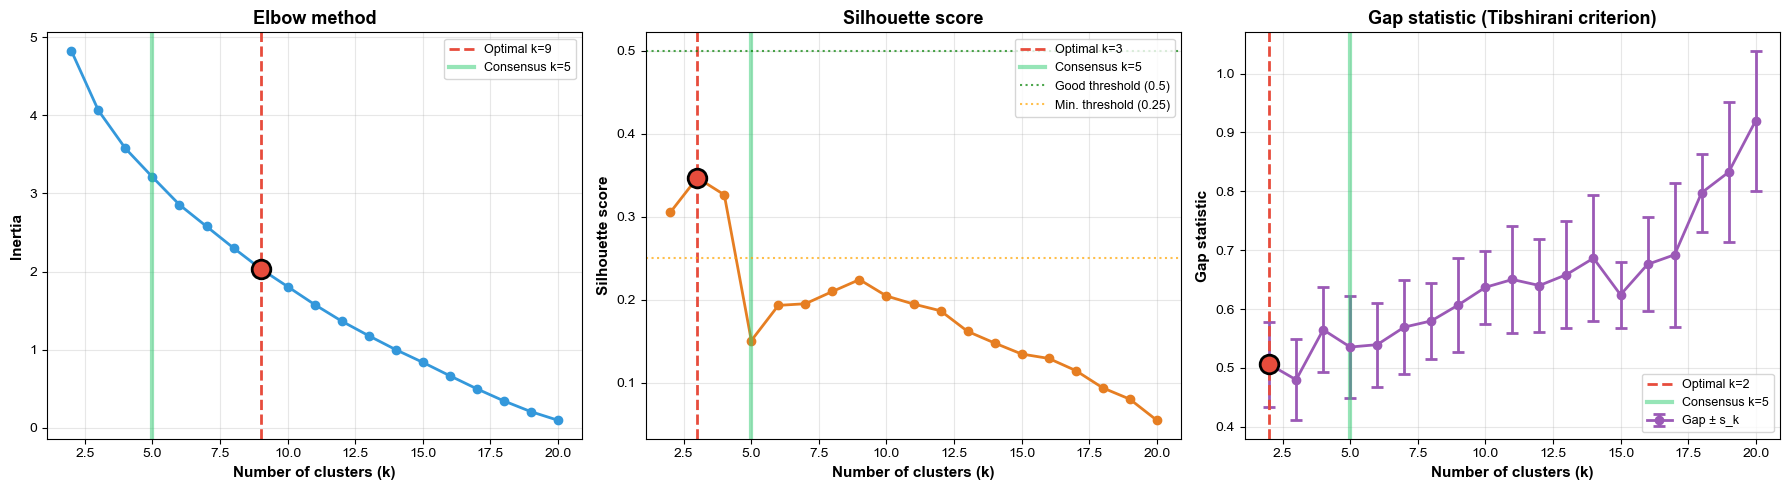


Optimal number of clusters: k* = 5

  Consensus: round(mean(9, 3, 2)) = round(4.67) = 5

  Metrics at k = 5:
    Inertia   : 3.21
    Silhouette: 0.151
    Gap       : 0.536

  Configuration:
    Random state : 42
    Iterations   : 100
    Range        : k = 2..20
    Hybrid dist. : True (alpha=0.107)

Metrics exported to output/optimal_clusters_metrics.csv


In [2]:
# =============================================================================
# 1. OPTIMAL NUMBER OF CLUSTERS — Elbow, Silhouette, Gap Statistic
# =============================================================================
#
# Consensus formula:  k* = round( mean(k_elbow, k_silhouette, k_gap) )
#
# References:
#   Elbow        — Thorndike (1953)
#   Silhouette   — Rousseeuw (1987)
#   Gap Statistic — Tibshirani, Walther & Hastie (2001)
# =============================================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
import kmedoids
import warnings

warnings.filterwarnings("ignore")

# =============================================================================
# 1.1 Configuration (must match Section 2)
# =============================================================================

DATA_PATH    = "output/Clustering.csv"
OUTPUT_DIR   = "output"
RANDOM_STATE = 42
USE_HYBRID_DISTANCE = True
ALPHA        = 0.107
MIN_K, MAX_K = 2, 21          # MAX_K is capped at n-1
N_ITERATIONS = 100             # runs per k for metric stability

os.makedirs(OUTPUT_DIR, exist_ok=True)

WEIGHTS = {
    # Energy infrastructure (0.306)
    "EL_network_access":          0.179,  # (15+13+30+10+20+25+12)/700
    "FG_network_access":          0.127,  # (10+9+10+5+20+25+10)/700
    "Gas_turbine":                0.000,
    "Diesel_genset":              0.000,
    # Demand & socio-economic (0.363)
    "EL_demand_scaled":           0.070,  # (10+10+5+7+10+6+1)/700
    "Population_density_scaled":  0.123,  # (10+13+10+15+10+10+18)/700
    "GDP_scaled":                 0.094,  # (5+9+20+5+10+5+12)/700
    "Num_vehicles_scaled":        0.057,  # (5+9+5+5+5+5+6)/700
    # Renewable resources (0.110)
    "Cp_Wind_scaled":             0.054,  # (10+7+0+5+5+5+6)/700
    "Cp_PV_scaled":               0.056,  # (10+5+0+10+5+7.5+2)/700
    # Climate & geography (0.114)
    "Altitude_scaled":            0.044,  # (3+4+5+10+2+1.5+5)/700
    "Temp_scaled":                0.031,  # (4+2+5+5+2+2.5+1)/700
    "Relative_humidity_scaled":   0.039,  # (3+3+5+10+1+1.5+4)/700
}
# Features: 0.893 + ALPHA: 0.107 = 1.000

# =============================================================================
# 1.2 Data preparation (mirrors Section 2)
# =============================================================================

data = pd.read_csv(DATA_PATH, sep=";")

# Rename column with space to underscore (required by the code)
data = data.rename(columns={"Population density": "Population_density"})

# Gas_turbine and Diesel_genset are absent from Norte Amazónica
# (no national gas infrastructure, no thermal power plants in the study area).
# Columns added as constants to preserve the methodology from Pablo's original
# notebook. Their weight is set to 0 in the WEIGHTS dict.
data["Gas_turbine"] = 0
data["Diesel_genset"] = 0

MAX_K = min(MAX_K, len(data) - 1)
k_values = list(range(MIN_K, MAX_K + 1))

scaler = StandardScaler()
for var in ["Population_density", "Cp_PV", "Cp_Wind", "Temp",
            "Relative_humidity", "Altitude", "EL_demand", "GDP", "Num_vehicles"]:
    data[f"{var}_scaled"] = scaler.fit_transform(data[[var]])

X = data[list(WEIGHTS.keys())].copy()
for var, w in WEIGHTS.items():
    X[var] *= w
X_array = X.values

distance_matrix = None
if USE_HYBRID_DISTANCE:
    n = len(data)
    geo_dist = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = geodesic(
                (data.iloc[i]["Latitude"], data.iloc[i]["Longitude"]),
                (data.iloc[j]["Latitude"], data.iloc[j]["Longitude"]),
            ).km
            geo_dist[i, j] = geo_dist[j, i] = d
    euc_dist = euclidean_distances(X_array)
    geo_norm = geo_dist / (geo_dist.max() + 1e-10)
    euc_norm = euc_dist / (euc_dist.max() + 1e-10)
    distance_matrix = ALPHA * geo_norm + (1 - ALPHA) * euc_norm

print(f"Data ready: {len(data)} municipalities, k range [{MIN_K}, {MAX_K}], "
      f"{N_ITERATIONS} iterations/k")

# =============================================================================
# 1.3 Helper functions
# =============================================================================

def find_elbow(k_vals, inertias):
    """Return k at maximum perpendicular distance to the first–last line."""
    x = np.array(k_vals, dtype=float)
    y = np.array(inertias, dtype=float)
    xn = (x - x.min()) / (x.max() - x.min() + 1e-10)
    yn = (y - y.min()) / (y.max() - y.min() + 1e-10)
    p1, p2 = np.array([xn[0], yn[0]]), np.array([xn[-1], yn[-1]])
    dists = [
        abs((p2[0]-p1[0])*(p1[1]-yn[i]) - (p1[0]-xn[i])*(p2[1]-p1[1]))
        / (np.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2) + 1e-10)
        for i in range(len(xn))
    ]
    return int(x[np.argmax(dists)])


def find_optimal_silhouette(k_vals, scores):
    """Return k that maximises the silhouette score."""
    return k_vals[np.argmax(scores)]


def find_optimal_gap(k_vals, gaps, s_k):
    """Tibshirani criterion: smallest k where Gap(k) >= Gap(k+1) - s_{k+1}."""
    for i in range(len(gaps) - 1):
        if gaps[i] >= gaps[i + 1] - s_k[i + 1]:
            return k_vals[i]
    return k_vals[np.argmax(gaps)]

# =============================================================================
# 1.4 Compute metrics (inertia + silhouette, averaged over N_ITERATIONS)
# =============================================================================

use_pre = distance_matrix is not None
inertias_avg, sils_avg = [], []

print("\nComputing inertia & silhouette ...")
for k in k_values:
    iner_list, sil_list = [], []
    D_fit = distance_matrix if use_pre else euclidean_distances(X_array)
    for it in range(N_ITERATIONS):
        seed = RANDOM_STATE + it
        result = kmedoids.fasterpam(D_fit, k, max_iter=300, random_state=seed)
        labels = np.array(result.labels)
        iner_list.append(float(result.loss))
        sil_list.append(silhouette_score(
            distance_matrix if use_pre else X_array, labels,
            metric="precomputed" if use_pre else "euclidean"))
    inertias_avg.append(np.mean(iner_list))
    sils_avg.append(np.mean(sil_list))
    print(f"  k={k:2d}  inertia={inertias_avg[-1]:.2f}  silhouette={sils_avg[-1]:.3f}")

# =============================================================================
# 1.5 Gap Statistic
# =============================================================================

N_REFS = 20
gaps, s_k = [], []
np.random.seed(RANDOM_STATE)

print("\nComputing Gap Statistic ...")
for k in k_values:
    D_fit = distance_matrix if use_pre else euclidean_distances(X_array)
    result = kmedoids.fasterpam(D_fit, k, max_iter=300, random_state=RANDOM_STATE)
    W_k = float(result.loss)

    ref_lw = []
    for b in range(N_REFS):
        rd = np.random.uniform(low=X_array.min(axis=0),
                               high=X_array.max(axis=0), size=X_array.shape)
        if use_pre:
            rd_d = euclidean_distances(rd)
            rd_d = rd_d / (rd_d.max() + 1e-10)
        else:
            rd_d = rd
        result_r = kmedoids.fasterpam(rd_d, k, max_iter=300, random_state=RANDOM_STATE + b)
        ref_lw.append(np.log(float(result_r.loss) + 1e-10))

    mlw = np.mean(ref_lw)
    gaps.append(mlw - np.log(W_k + 1e-10))
    s_k.append(np.sqrt(np.mean((np.array(ref_lw) - mlw) ** 2)) * np.sqrt(1 + 1 / N_REFS))
    print(f"  k={k:2d}  gap={gaps[-1]:.3f}")

# =============================================================================
# 1.6 Optimal k per method & consensus
# =============================================================================

k_elbow      = find_elbow(k_values, inertias_avg)
k_silhouette = find_optimal_silhouette(k_values, sils_avg)
k_gap        = find_optimal_gap(k_values, gaps, s_k)

avg_k       = np.mean([k_elbow, k_silhouette, k_gap])
k_consensus = round(avg_k)

print(f"\n{'='*60}")
print(f"  Elbow       : k = {k_elbow}")
print(f"  Silhouette  : k = {k_silhouette}")
print(f"  Gap Statistic: k = {k_gap}")
print(f"{'─'*60}")
print(f"  Consensus   : k* = round({avg_k:.2f}) = {k_consensus}")
print(f"{'='*60}")

# =============================================================================
# 1.7 Summary table
# =============================================================================

summary = pd.DataFrame({
    "k":          k_values,
    "Inertia":    [f"{v:.2f}" for v in inertias_avg],
    "Silhouette": [f"{v:.3f}" for v in sils_avg],
    "Gap":        [f"{v:.3f}" for v in gaps],
})

methods = []
for k in k_values:
    m = []
    if k == k_elbow:      m.append("E")
    if k == k_silhouette: m.append("S")
    if k == k_gap:        m.append("G")
    methods.append(",".join(m) if m else "-")
summary["Method"] = methods

print("\n" + summary.to_string(index=False))
print("\nLegend: E = Elbow, S = Silhouette, G = Gap Statistic")

# =============================================================================
# 1.8 Visualisation (3-panel figure)
# =============================================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

OPT_COLOR = "#E74C3C"
CON_COLOR = "#2ECC71"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Elbow ---
ax = axes[0]
ax.plot(k_values, inertias_avg, "o-", lw=2, ms=6, color="#3498DB")
ax.axvline(k_elbow, color=OPT_COLOR, ls="--", lw=2, label=f"Optimal k={k_elbow}")
ax.axvline(k_consensus, color=CON_COLOR, ls="-", lw=3, alpha=0.5,
           label=f"Consensus k={k_consensus}")
ax.scatter([k_elbow], [inertias_avg[k_values.index(k_elbow)]],
           color=OPT_COLOR, s=180, zorder=5, edgecolor="black", lw=2)
ax.set_xlabel("Number of clusters (k)", fontsize=11, weight="bold")
ax.set_ylabel("Inertia", fontsize=11, weight="bold")
ax.set_title("Elbow method", fontsize=13, weight="bold")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

# --- Silhouette ---
ax = axes[1]
ax.plot(k_values, sils_avg, "o-", lw=2, ms=6, color="#E67E22")
ax.axvline(k_silhouette, color=OPT_COLOR, ls="--", lw=2,
           label=f"Optimal k={k_silhouette}")
ax.axvline(k_consensus, color=CON_COLOR, ls="-", lw=3, alpha=0.5,
           label=f"Consensus k={k_consensus}")
ax.axhline(0.5, color="green", ls=":", alpha=0.7, label="Good threshold (0.5)")
ax.axhline(0.25, color="orange", ls=":", alpha=0.7, label="Min. threshold (0.25)")
ax.scatter([k_silhouette], [sils_avg[k_values.index(k_silhouette)]],
           color=OPT_COLOR, s=180, zorder=5, edgecolor="black", lw=2)
ax.set_xlabel("Number of clusters (k)", fontsize=11, weight="bold")
ax.set_ylabel("Silhouette score", fontsize=11, weight="bold")
ax.set_title("Silhouette score", fontsize=13, weight="bold")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc="upper right")

# --- Gap Statistic ---
ax = axes[2]
ax.errorbar(k_values, gaps, yerr=s_k, marker="o", lw=2, ms=6,
            capsize=4, color="#9B59B6", capthick=2, label="Gap ± s_k")
ax.axvline(k_gap, color=OPT_COLOR, ls="--", lw=2, label=f"Optimal k={k_gap}")
ax.axvline(k_consensus, color=CON_COLOR, ls="-", lw=3, alpha=0.5,
           label=f"Consensus k={k_consensus}")
ax.scatter([k_gap], [gaps[k_values.index(k_gap)]],
           color=OPT_COLOR, s=180, zorder=5, edgecolor="black", lw=2)
ax.set_xlabel("Number of clusters (k)", fontsize=11, weight="bold")
ax.set_ylabel("Gap statistic", fontsize=11, weight="bold")
ax.set_title("Gap statistic (Tibshirani criterion)", fontsize=13, weight="bold")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/optimal_clusters_evaluation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/optimal_clusters_evaluation.pdf", format="pdf", bbox_inches="tight")
plt.show()

# =============================================================================
# 1.9 Final summary
# =============================================================================

idx_c = k_values.index(k_consensus)
print(f"""
Optimal number of clusters: k* = {k_consensus}

  Consensus: round(mean({k_elbow}, {k_silhouette}, {k_gap})) = round({avg_k:.2f}) = {k_consensus}

  Metrics at k = {k_consensus}:
    Inertia   : {inertias_avg[idx_c]:.2f}
    Silhouette: {sils_avg[idx_c]:.3f}
    Gap       : {gaps[idx_c]:.3f}

  Configuration:
    Random state : {RANDOM_STATE}
    Iterations   : {N_ITERATIONS}
    Range        : k = {MIN_K}..{MAX_K}
    Hybrid dist. : {USE_HYBRID_DISTANCE} (alpha={ALPHA})
""")

summary.to_csv(f"{OUTPUT_DIR}/optimal_clusters_metrics.csv", index=False)
print(f"Metrics exported to {OUTPUT_DIR}/optimal_clusters_metrics.csv")

Weight check passed: features=0.87, alpha=0.13, total=1.00
Loaded 21 municipalities, 15 columns
Hybrid distance matrix built (alpha=0.126)
Clustering complete: k=5, inertia=3.2252, silhouette=0.1530

 Cluster 0 (4 municipalities): Exaltación, Reyes, Santa_Rosa_Beni, Ixiamas
  FG=0%   PopD=0.6   GDP=2228.2  Temp=25.7°C
  Alt=188m  RH=78.5%   Num_vehicles=0.2  EL_dem=0.7  
 Cluster 1 (1 municipalities): Bolpebra
  FG=0%   PopD=0.9   GDP=5329.0  Temp=25.8°C
  Alt=233m  RH=82.1%   Num_vehicles=0.3  EL_dem=0.0  
 Cluster 2 (3 municipalities): Guayaramerín, Riberalta, Puerto_Gonzalo_Moreno
  FG=67%   PopD=8.9   GDP=1771.7  Temp=26.4°C
  Alt=134m  RH=83.2%   Num_vehicles=0.2  EL_dem=0.9  
 Cluster 3 (12 municipalities): Bella_Flor, Filadelfia, Ingavi, Nueva_Esperanza, Porvenir, Puerto_Rico, San_Lorenzo, San_Pedro, Santa_Rosa_Pando, Santos_Mercado, Sena, Villa_Nueva
  FG=0%   PopD=1.4   GDP=2350.4  Temp=26.5°C
  Alt=174m  RH=81.8%   Num_vehicles=0.2  EL_dem=0.5  
 Cluster 4 (1 municipalities):

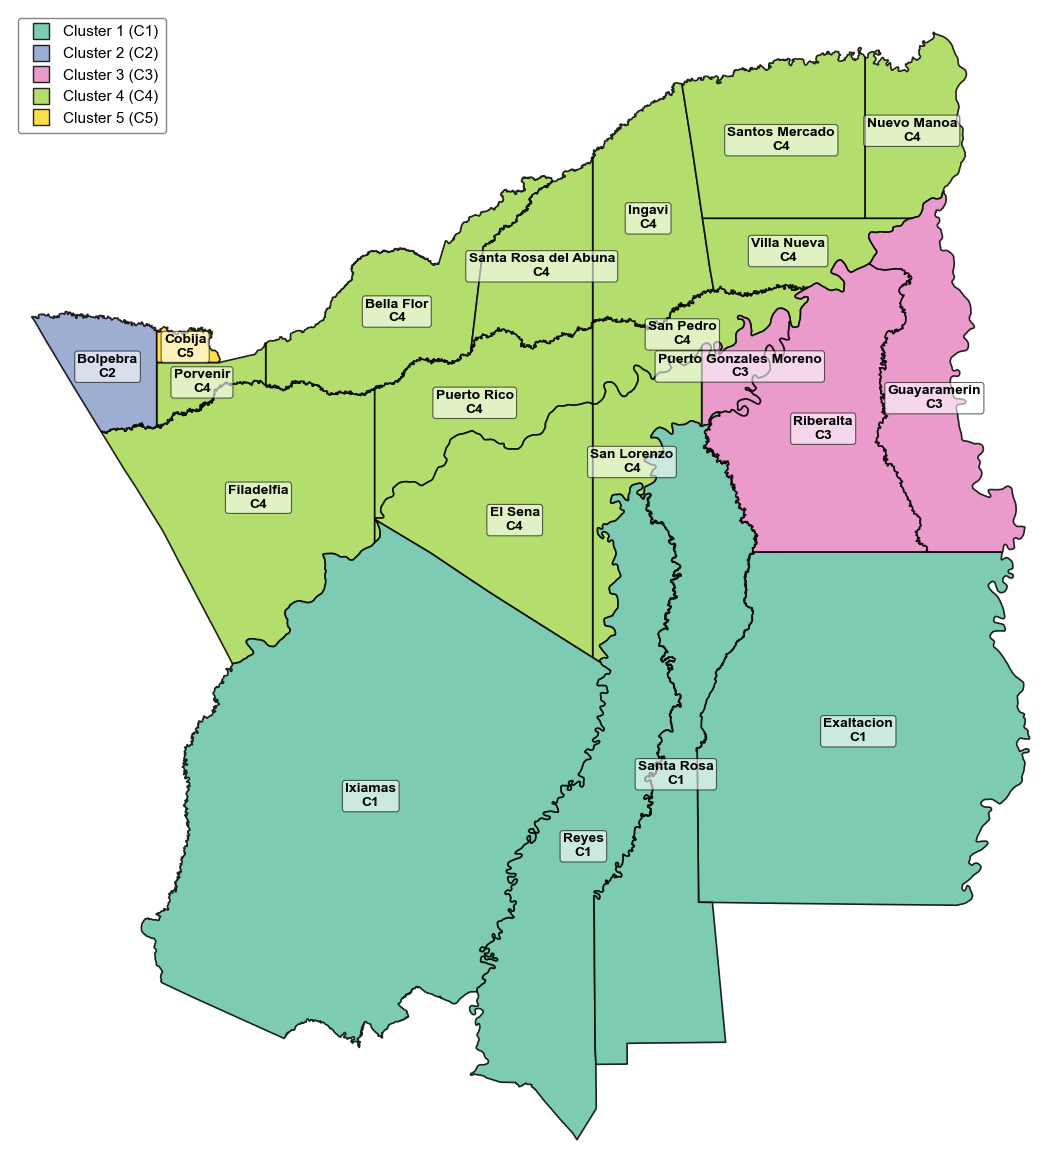

Map saved (PNG + PDF).


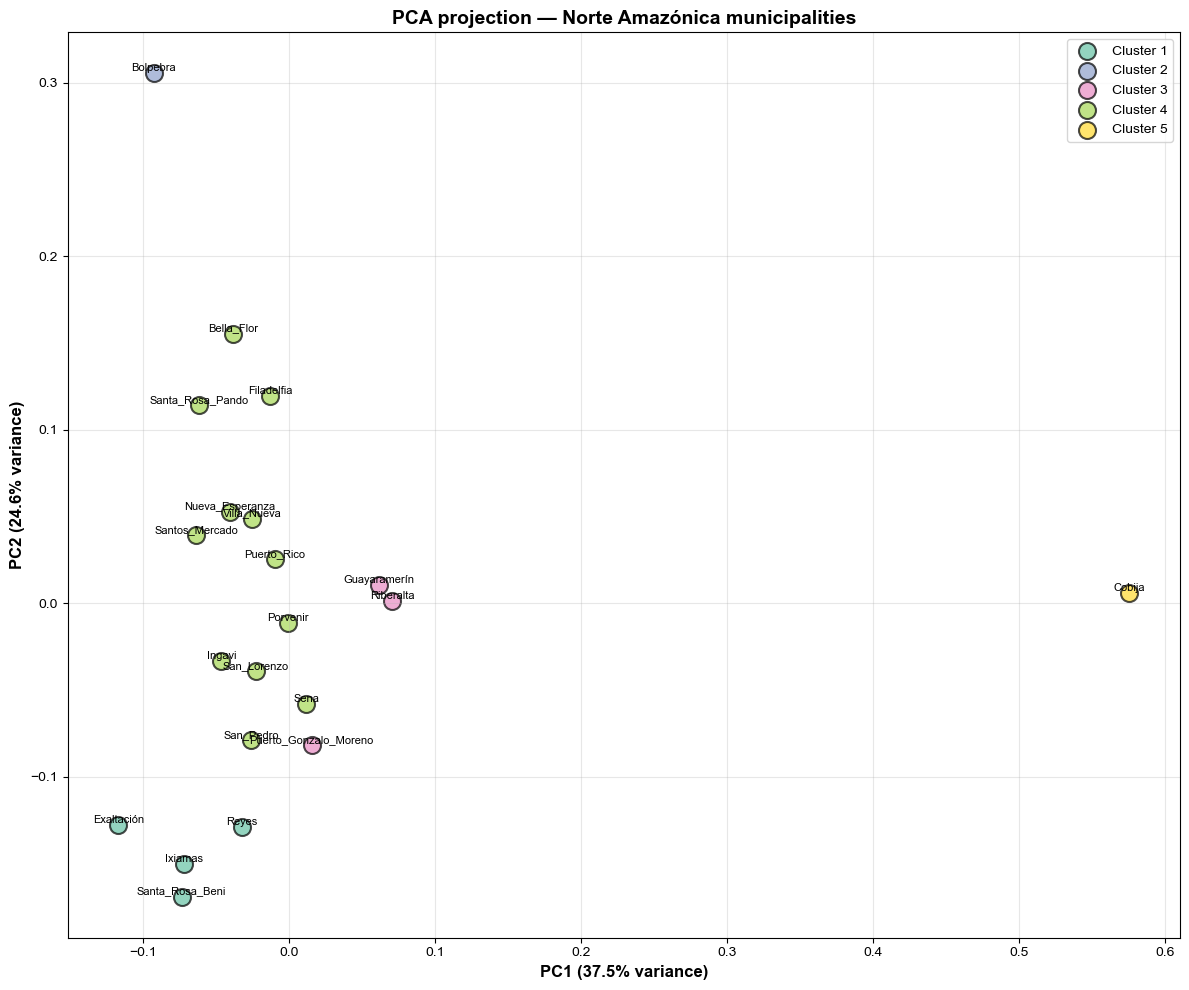

Results exported to output/clustering_results.csv

CLUSTERING SUMMARY — Norte Amazónica
Total municipalities: 21
Number of clusters: 5
Silhouette score: 0.1530

Municipalities per cluster:
  Cluster 1: Exaltación, Reyes, Santa_Rosa_Beni, Ixiamas
  Cluster 2: Bolpebra
  Cluster 3: Guayaramerín, Riberalta, Puerto_Gonzalo_Moreno
  Cluster 4: Bella_Flor, Filadelfia, Ingavi, Nueva_Esperanza, Porvenir, Puerto_Rico, San_Lorenzo, San_Pedro, Santa_Rosa_Pando, Santos_Mercado, Sena, Villa_Nueva
  Cluster 5: Cobija


In [7]:
# =============================================================================
# 2. CLUSTERING — K-Medoids with hybrid distances
# =============================================================================

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import kmedoids
import warnings

warnings.filterwarnings("ignore")

# =============================================================================
# 2.1 Configuration
# =============================================================================

# Paths (local, relative to notebook directory)
DATA_PATH   = "output/Clustering.csv"
OUTPUT_DIR  = "output"
MAP_PATH    = "../GeoJSon/norte_amazonica_21.geojson"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clustering parameters
K_CLUSTERS          = 5
RANDOM_STATE        = 42
USE_HYBRID_DISTANCE = True
ALPHA = 0.126

WEIGHTS = {
    # Energy infrastructure (0.306)
    "EL_network_access":          0.179,  # (15+13+30+10+20+25+12)/700
    "FG_network_access":          0.127,  # (10+9+10+5+20+25+10)/700
    "Gas_turbine":                0.000,
    "Diesel_genset":              0.000,
    # Demand & socio-economic (0.363)
    "EL_demand_scaled":           0.070,  # (10+10+5+7+10+6+1)/700
    "Population_density_scaled":  0.123,  # (10+13+10+15+10+10+18)/700
    "GDP_scaled":                 0.094,  # (5+9+20+5+10+5+12)/700
    "Num_vehicles_scaled":        0.057,  # (5+9+5+5+5+5+6)/700
    # Renewable resources (0.110)
    "Cp_Wind_scaled":             0.054,  # (10+7+0+5+5+5+6)/700
    "Cp_PV_scaled":               0.056,  # (10+5+0+10+5+7.5+2)/700
    # Climate & geography (0.114)
    "Altitude_scaled":            0.044,  # (3+4+5+10+2+1.5+5)/700
    "Temp_scaled":                0.031,  # (4+2+5+5+2+2.5+1)/700
    "Relative_humidity_scaled":   0.039,  # (3+3+5+10+1+1.5+4)/700
}
# Features: 0.893 + ALPHA: 0.107 = 1.000

# WEIGHTS = {
#     # Energy infrastructure (0.22)
#     "EL_network_access":          0.12,  # 4/21 connected to SIN
#     "FG_network_access":          0.10,  # 3/21 with gas network
#     "Gas_turbine":                0.00,  # Absent in Norte Amazónica
#     "Diesel_genset":              0.00,  # Absent in Norte Amazónica
#     # Demand & socio-economic (0.40)
#     "EL_demand_scaled":           0.04,  # 5/21 = 0 by missing data (MWh/person/year)
#     "Population_density_scaled":  0.18,  # Urban vs rural (Cobija = outlier)
#     "GDP_scaled":                 0.12,  # Economic level
#     "Num_vehicles_scaled":        0.06,  # Development proxy
#     # Renewable resources (0.08)
#     "Cp_Wind_scaled":             0.06,
#     "Cp_PV_scaled":               0.02,  # Near-constant (17-18%) in the zone
#     # Climate & geography (0.10)
#     "Altitude_scaled":            0.05,  # Discriminates Ixiamas (265m)
#     "Temp_scaled":                0.01,  # Near-constant tropical climate
#     "Relative_humidity_scaled":   0.04,  # Low variance
# }
# Features: 0.80 + ALPHA: 0.20 = 1.00

# ---- Weight verification ----
_w_sum    = sum(WEIGHTS.values())
_expected = 1.0 - ALPHA if USE_HYBRID_DISTANCE else 1.0
assert abs(_w_sum + (ALPHA if USE_HYBRID_DISTANCE else 0) - 1.0) < 1e-3, \
    f"Weights do not sum to 1.0 (got {_w_sum + ALPHA:.4f})"
print(f"Weight check passed: features={_w_sum:.2f}, alpha={ALPHA:.2f}, total=1.00")

# =============================================================================
# 2.2 Load & standardise data
# =============================================================================

data = pd.read_csv(DATA_PATH, sep=";")
print(f"Loaded {len(data)} municipalities, {data.shape[1]} columns")

# Rename column with space to underscore (required by the code)
data = data.rename(columns={"Population density": "Population_density"})

# Gas_turbine and Diesel_genset are absent from Norte Amazónica
# (no national gas infrastructure, no thermal power plants in the study area).
# Columns added as constants to preserve the methodology from Pablo's original
# notebook. Their weight is set to 0 in the WEIGHTS dict.
data["Gas_turbine"] = 0
data["Diesel_genset"] = 0

CONTINUOUS_VARS = [
    "Population_density", "Cp_PV", "Cp_Wind", "Temp",
    "Relative_humidity", "Altitude", "EL_demand", "GDP", "Num_vehicles",
]
BINARY_VARS = ["FG_network_access", "EL_network_access", "Gas_turbine", "Diesel_genset"]

scaler = StandardScaler()
for var in CONTINUOUS_VARS:
    data[f"{var}_scaled"] = scaler.fit_transform(data[[var]])

# =============================================================================
# 2.3 Build weighted feature matrix & distance matrix
# =============================================================================

clustering_vars = list(WEIGHTS.keys())
X = data[clustering_vars].copy()
for var, w in WEIGHTS.items():
    X[var] *= w
X_array = X.values

distance_matrix = None

if USE_HYBRID_DISTANCE:
    # Geodesic distances (km) — Vincenty on WGS-84
    n = len(data)
    geo_dist = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = geodesic(
                (data.iloc[i]["Latitude"], data.iloc[i]["Longitude"]),
                (data.iloc[j]["Latitude"], data.iloc[j]["Longitude"]),
            ).km
            geo_dist[i, j] = geo_dist[j, i] = d

    euc_dist = euclidean_distances(X_array)

    # Normalise both to [0, 1] and combine
    geo_norm = geo_dist / (geo_dist.max() + 1e-10)
    euc_norm = euc_dist / (euc_dist.max() + 1e-10)
    distance_matrix = ALPHA * geo_norm + (1 - ALPHA) * euc_norm
    print(f"Hybrid distance matrix built (alpha={ALPHA})")

# =============================================================================
# 2.4 K-Medoids clustering
# =============================================================================

k_eff = min(K_CLUSTERS, len(data) - 1)

D_fit = distance_matrix if USE_HYBRID_DISTANCE else euclidean_distances(X_array)
km_result = kmedoids.fasterpam(D_fit, k_eff, max_iter=300, random_state=RANDOM_STATE)
data["Cluster"] = np.array(km_result.labels)

sil_score = silhouette_score(
    distance_matrix if USE_HYBRID_DISTANCE else X_array,
    data["Cluster"],
    metric="precomputed" if USE_HYBRID_DISTANCE else "euclidean",
)

print(f"Clustering complete: k={k_eff}, inertia={km_result.loss:.4f}, "
      f"silhouette={sil_score:.4f}")

# =============================================================================
# 2.5 Medoids & cluster characteristics
# =============================================================================

print()
for cid in sorted(data["Cluster"].unique()):
    cd = data[data["Cluster"] == cid]
    munis = ", ".join(cd["Municipio"].tolist())
    print(f" Cluster {cid} ({len(cd)} municipalities): {munis}")
    print(f"  FG={cd['FG_network_access'].mean()*100:.0f}%   PopD={cd['Population_density'].mean():.1f}   "
          f"GDP={cd['GDP'].mean():.1f}  Temp={cd['Temp'].mean():.1f}°C")
    print(f"  Alt={cd['Altitude'].mean():.0f}m  RH={cd['Relative_humidity'].mean():.1f}%   "
          f"Num_vehicles={cd['Num_vehicles'].mean():.1f}  EL_dem={cd['EL_demand'].mean():.1f}  ")

# Summary table
summary = data.groupby("Cluster").agg({
    "Municipio": "count", "FG_network_access": "mean", "Population_density": "mean",
    "GDP": "mean", "Temp": "mean", "Altitude": "mean", "Relative_humidity": "mean",
    "Num_vehicles": "mean", "EL_demand": "mean",
}).round(3)
summary.columns = ["N_mun", "FG%", "PopD", "GDP", "Temp",
                   "Alt", "RH", "Num_vehicles", "EL_dem"]
print("\nSummary table:\n", summary.to_string())

# =========================================================================
# 2.6 Map visualisation
# =========================================================================
import geopandas as gpd

print("Generating map visualization...")
gdata = gpd.read_file(MAP_PATH)

# Dictionnaire pour traduire les noms de ton CSV vers les noms exacts du GeoJSON
name_mapping = {
    # Accents retirés (noms GeoJSON sans accents)
    "Exaltación":            "Exaltacion",
    "Guayaramerín":          "Guayaramerin",
    # Noms GeoJSON différents du CSV (underscores → espaces, ou nom distinct)
    "Santa_Rosa_Beni":       "Santa Rosa",
    "Santa Rosa Beni":       "Santa Rosa",
    "Bella_Flor":            "Bella Flor",
    "Bolpebra":              "Bolpebra (Mukden)",
    "Nueva_Esperanza":       "Nuevo Manoa (Nueva Esperanza)",
    "Nueva Esperanza":       "Nuevo Manoa (Nueva Esperanza)",
    "Puerto_Gonzalo_Moreno": "Puerto Gonzales Moreno",
    "Puerto Gonzalo Moreno": "Puerto Gonzales Moreno",
    "Puerto_Rico":           "Puerto Rico",
    "San_Lorenzo":           "San Lorenzo",
    "San_Pedro":             "San Pedro (Conquista)",
    "San Pedro":             "San Pedro (Conquista)",
    "Santa_Rosa_Pando":      "Santa Rosa del Abuna",
    "Santa Rosa Pando":      "Santa Rosa del Abuna",
    "Santos_Mercado":        "Santos Mercado",
    "Sena":                  "El Sena",
    "Villa_Nueva":           "Villa Nueva (Loma Alta)",
    "Villa Nueva":           "Villa Nueva (Loma Alta)",
}

# On prépare tes données pour la fusion
data_for_map = data[["Municipio", "Cluster"]].copy()
# On applique la traduction (si le nom n'est pas dans le dico, on le garde tel quel)
data_for_map["GeoJSON_Name"] = data_for_map["Municipio"].map(lambda x: name_mapping.get(x, x))

# Fusion des géométries avec tes clusters
merged = gdata.merge(data_for_map, left_on="NOM_MUN", right_on="GeoJSON_Name", how="left")
merged["Cluster"] = merged["Cluster"].fillna(-1).astype(int)

# Couleurs pour la carte et le PCA
JOURNAL_COLORS = {
    0: "#66C2A5", 1: "#8DA0CB", 2: "#E78AC3",
    3: "#A6D854", 4: "#FFD92F", 5: "#FC8D62", -1: "#D9D9D9",
}
color_map = {c: JOURNAL_COLORS.get(c, "#D9D9D9") for c in sorted(merged["Cluster"].unique())}
merged["Color"] = merged["Cluster"].map(color_map)

# Création de la figure
fig, ax = plt.subplots(figsize=(12, 12))
merged.plot(ax=ax, color=merged["Color"], alpha=0.85, edgecolor="black", linewidth=1.2)

# Ajuster le zoom de la carte
minx, miny, maxx, maxy = merged.total_bounds
ax.set_xlim(minx - 0.1, maxx + 0.1)
ax.set_ylim(miny - 0.1, maxy + 0.1)

# Placer les étiquettes (Nom + Cluster)
for _, row in merged.iterrows():
    if row.geometry is None:
        continue
    # Calculer le centre de la municipalité pour placer le texte
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    
    # Nettoyer le nom pour l'affichage (enlever les parenthèses ex: "(Mukden)")
    name = str(row["NOM_MUN"]).split(" (")[0]
    cid  = int(row["Cluster"]) + 1 if row["Cluster"] != -1 else "N/A"
    
    # Dessiner le texte avec un fond blanc semi-transparent pour être lisible
    ax.text(cx, cy, f"{name}\nC{cid}", fontsize=10, ha="center", va="center", weight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", linewidth=0.8, alpha=0.6))

# Légende
handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=color_map[c], markersize=12, alpha=0.85,
           label=f"Cluster {c+1} (C{c+1})", markeredgecolor="black", markeredgewidth=1)
    for c in sorted(c for c in data["Cluster"].unique() if c != -1)
]
ax.axis("off")
ax.legend(handles=handles, loc="upper left", frameon=True, edgecolor="gray",
          facecolor="white", fontsize=11, framealpha=0.95, borderpad=0.5, handletextpad=0.5)

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
plt.savefig(f"{OUTPUT_DIR}/clustering_map_journal.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/clustering_map_journal.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Map saved (PNG + PDF).")

# =============================================================================
# 2.7 PCA visualisation
# =============================================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_array)

fig, ax = plt.subplots(figsize=(12, 10))
for cid in sorted(data["Cluster"].unique()):
    mask = data["Cluster"] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=150,
               alpha=0.7, edgecolor="black", linewidth=1.5,
               label=f"Cluster {cid+1}", color=color_map[cid])
    for idx in data[mask].index:
        ax.annotate(data.loc[idx, "Municipio"],
                    (X_pca[idx, 0], X_pca[idx, 1]), fontsize=8,
                    ha="center", va="bottom")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12, weight="bold")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12, weight="bold")
ax.set_title("PCA projection — Norte Amazónica municipalities", fontsize=14, weight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/clustering_pca.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# 2.8 Export results
# =============================================================================

results_df = data[[
    "Municipio", "Cluster",
    "EL_network_access", "FG_network_access", "Gas_turbine", "Diesel_genset",
    "Population_density", "GDP", "Cp_PV", "Cp_Wind", "Temp", "Altitude",
    "Relative_humidity", "Num_vehicles", "EL_demand",
]].sort_values(["Cluster", "Municipio"])

results_df.to_csv(f"{OUTPUT_DIR}/clustering_results.csv", index=False)
print(f"Results exported to {OUTPUT_DIR}/clustering_results.csv")

# =============================================================================
# 2.9 Final sanity summary
# =============================================================================

print("\n" + "=" * 60)
print("CLUSTERING SUMMARY — Norte Amazónica")
print("=" * 60)
print(f"Total municipalities: {len(data)}")
print(f"Number of clusters: {k_eff}")
print(f"Silhouette score: {sil_score:.4f}")
print("\nMunicipalities per cluster:")
for cid in sorted(data["Cluster"].unique()):
    munis = data[data["Cluster"] == cid]["Municipio"].tolist()
    print(f"  Cluster {cid+1}: {', '.join(munis)}")